# Analisis Exploratorio Detallado: Video Games Sales (1980-2024)

Este notebook documenta un EDA (Exploratory Data Analysis) profundo para entender el dataset de ventas de videojuegos.

El objetivo es que cualquier persona, incluso sin contexto previo, pueda leer este documento y entender:
- que representa cada variable,
- si es cuantitativa o cualitativa,
- que problemas de calidad de datos existen,
- que columnas requieren formateo o limpieza,
- que variables aportan (o no) informacion para analisis posteriores.

## 0) Comprension del problema y decision de negocio

### Problema que se resuelve
Este trabajo aborda un problema **descriptivo-diagnostico**: entender como se comporta el mercado de videojuegos por plataforma, genero, region y periodo temporal, usando un dataset historico de ventas y score critico.

### Usuario final
El analisis esta orientado a un **analista de marketing y portafolio** en una publicadora/distribuidora de videojuegos.

### Decisiones que este analisis puede habilitar
1. Priorizar plataformas y generos para nuevos lanzamientos.
2. Ajustar presupuesto de marketing por region (NA, JP, PAL, Other).
3. Detectar periodos de alta saturacion y oportunidades de nicho.
4. Definir combinaciones de variables para un futuro modelo predictivo de ventas.

### Variable de negocio mas sensible
La variable mas critica para toma de decisiones es `total_sales` (junto a su desglose regional), porque representa resultado comercial directo.

### Riesgos de mala interpretacion
- Confundir **correlacion** con causalidad (por ejemplo, score alto no implica por si solo ventas altas).
- Ignorar sesgos de cobertura del dataset (periodos o plataformas sobrerrepresentadas).
- No tratar inconsistencias entre ventas regionales y venta total.

### Criterio metodologico de este notebook
- Se justifican explicitamente decisiones de limpieza.
- Se compara enfoque con y sin imputacion para `critic_score`.
- Se adopta una regla hibrida para consistencia de ventas, documentada y trazable.

## 1) Objetivos y alcance

### Objetivos del EDA
1. Auditar estructura y calidad del dataset.
2. Clasificar variables (cuantitativas/cualitativas, continuas/discretas, nominales/temporales).
3. Detectar valores faltantes, formatos incorrectos, incoherencias y potenciales duplicados.
4. Evaluar utilidad analitica de cada columna para modelado, dashboards o reportes.
5. Proponer una ruta de limpieza priorizada.

### Antes de empezar a codificar

En el siguiente bloque se configura el entorno de trabajo (librerias, opciones de visualizacion y formato de salida).

Por que se hace:
- Garantiza que todas las tablas y graficos se muestren de forma consistente.
- Mejora la legibilidad del analisis para terceros.
- Evita diferencias de formato entre ejecuciones.

In [3]:
# Configuracion general
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

### Resultado de la configuracion

El entorno queda listo para ejecutar el EDA de forma reproducible:
- Librerias cargadas correctamente.
- Estilo grafico uniforme.
- Formato de salida numerica consistente.

Interpretacion: a partir de aqui, los resultados del notebook son comparables entre ejecuciones y mas faciles de comunicar.

## 2) Carga de datos y vista inicial

### Que se va a hacer
En este bloque vamos a cargar el archivo CSV original, verificar su tamaño (filas y columnas) y observar una muestra de registros.

### Por que se hace
Este paso valida que estamos leyendo la fuente correcta y nos da una primera intuicion del contenido real del dataset (campos disponibles, formato y ejemplos de valores). Sin esta validacion inicial, cualquier analisis posterior podria basarse en una carga incorrecta.

In [4]:
# Carga del dataset
csv_path = Path('Video Games Sales (1980-2024) - Raw.csv')
df = pd.read_csv(csv_path)

print(f'Ruta: {csv_path.resolve()}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head(5)

Ruta: /home/juliancelis/Documents/universidad/octavo_semestre/mineria de datos/mineria/videoGames/Video Games Sales (1980-2024) - Raw.csv
Filas: 64,016 | Columnas: 14


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4000,20.3200,6.3700,0.9900,9.8500,3.1200,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7000,19.3900,6.0600,0.6000,9.7100,3.0200,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6000,16.1500,8.4100,0.4700,5.4900,1.7800,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.8600,9.0600,0.0600,5.3300,1.4200,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1000,15.0900,6.1800,0.4100,6.0500,2.4400,06-11-2015,14-01-2018


### Interpretacion de vista inicial (`head`)

La muestra inicial confirma que el archivo se cargo correctamente y permite validar que las columnas clave (`title`, `console`, `genre`, ventas y fechas) estan presentes.

Utilidad:
- Detectar temprano columnas inesperadas o faltantes.
- Verificar formato de valores antes de cualquier transformacion.
- Evitar continuar el analisis sobre una fuente incorrecta.

In [5]:
# Estructura general y tipos iniciales
display(df.info())
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
img,64016,56177,/games/boxart/default.jpg,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,"6,678.0000",NaN,NaN,NaN,7.2204,1.4571,1.0000,6.4000,7.5000,8.3000,10.0000
total_sales,"18,922.0000",NaN,NaN,NaN,0.3491,0.8075,0.0000,0.0300,0.1200,0.3400,20.3200
na_sales,"12,637.0000",NaN,NaN,NaN,0.2647,0.4948,0.0000,0.0500,0.1200,0.2800,9.7600
jp_sales,"6,726.0000",NaN,NaN,NaN,0.1023,0.1688,0.0000,0.0200,0.0400,0.1200,2.1300


### Interpretacion de `info()` y `describe()` inicial

`info()` muestra estructura y tipos en bruto; `describe()` resume dispersion, percentiles y cardinalidad basica.

Hallazgo operativo:
- Las columnas de ventas y `critic_score` llegan con alta ausencia.
- El dataset necesita tipificacion formal antes de modelado.

Utilidad:
- Definir prioridades de limpieza con evidencia.
- Establecer linea base para comparar antes vs despues del curado.

### Resultado e interpretacion

- El dataset contiene 64016 filas y 14 columnas.
- Se observa una mezcla de variables categoricas, numericas y temporales.
- La primera auditoria muestra faltantes muy altos en variables de ventas y puntuacion critica.

Interpretacion: el dataset es util para EDA y analisis de negocio, pero no esta listo para modelado directo sin una estrategia formal de tratamiento de nulos y consistencia.

## 3) Diccionario inicial de variables

### Que se va a hacer
Se documentaran conceptualmente las columnas del dataset y luego se calculara un perfil por variable (tipo detectado, nulos, porcentaje de nulos y cardinalidad).

### Por que se hace
Antes de limpiar o modelar, es clave entender el significado de cada variable y su estado de calidad. Esta etapa transforma un CSV en un conjunto de variables con contexto de negocio y criterios tecnicos para decidir prioridades de limpieza.

A continuacion se presenta una tabla de referencia conceptual (antes de limpiar):

- **img**: ruta de imagen de portada.
- **title**: nombre del videojuego.
- **console**: plataforma/consola.
- **genre**: genero principal.
- **publisher**: empresa publicadora.
- **developer**: estudio desarrollador.
- **critic_score**: puntuacion de critica (escala aparente 0-10).
- **total_sales**: ventas globales (aparentemente en millones de unidades).
- **na_sales, jp_sales, pal_sales, other_sales**: ventas por region.
- **release_date**: fecha de lanzamiento.
- **last_update**: fecha de ultima actualizacion del registro.

In [6]:
# Perfilado de tipos, cardinalidad y nulos por columna
summary = pd.DataFrame({
    'dtype_inicial': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(dropna=True)
}).sort_values(['pct_nulos', 'unicos'], ascending=[False, False])
summary

,dtype_inicial,nulos,pct_nulos,unicos
critic_score,float64,57338,89.5700,89
jp_sales,float64,57290,89.4900,121
na_sales,float64,51379,80.2600,320
pal_sales,float64,51192,79.9700,256
other_sales,float64,48888,76.3700,133
last_update,str,46137,72.0700,1545
total_sales,float64,45094,70.4400,482
release_date,str,7051,11.0100,7922
developer,str,17,0.0300,8862
img,str,0,0.0000,56177


### Resultado e interpretacion

El perfil por variable confirma que:
- Existen columnas con alta completitud (title, console, genre, publisher).
- Otras columnas clave tienen faltantes severos (critic_score y ventas regionales/globales).
- `img` presenta cardinalidad muy alta y baja utilidad para analitica de negocio.

Interpretacion: conviene priorizar el trabajo sobre variables de ventas, fechas y score, y tratar `img` como campo auxiliar (no analitico).

## 4) Tipificacion analitica: cuantitativa vs cualitativa

### Que se va a hacer
Se clasificara cada variable desde una mirada analitica (no solo por el dtype tecnico): cuantitativa/cualitativa, temporal/nominal y nivel de cardinalidad.

### Por que se hace
El tipo analitico determina que tecnicas aplicar: estadistica descriptiva, visualizaciones, imputacion, codificacion, agregaciones o transformaciones. Esta tipificacion evita errores comunes como tratar categorias como numericas o viceversa.

En esta seccion clasificamos cada variable de forma analitica (no solo por dtype de pandas).

In [7]:
# Clasificacion manual asistida
clasificacion = pd.DataFrame([
    ['img', 'Cualitativa nominal (identificador de recurso)', 'Alta cardinalidad', 'Puede no aportar para analisis de negocio'],
    ['title', 'Cualitativa nominal', 'Alta cardinalidad', 'Clave para agrupar; revisar duplicados por version/plataforma'],
    ['console', 'Cualitativa nominal', 'Baja/Media cardinalidad', 'Muy util para segmentacion'],
    ['genre', 'Cualitativa nominal', 'Baja cardinalidad', 'Muy util para perfil de mercado'],
    ['publisher', 'Cualitativa nominal', 'Media/Alta cardinalidad', 'Util para concentracion de mercado'],
    ['developer', 'Cualitativa nominal', 'Media/Alta cardinalidad', 'Util, pero suele tener variaciones de escritura'],
    ['critic_score', 'Cuantitativa continua', 'Escala numerica', 'Puede requerir convertir de texto a numerico y tratar nulos'],
    ['total_sales', 'Cuantitativa continua', 'Magnitud de ventas', 'Variable objetivo clave'],
    ['na_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['jp_sales', 'Cuantitativa continua', 'Magnitud regional', 'Posibles nulos/celdas vacias en CSV'],
    ['pal_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['other_sales', 'Cuantitativa continua', 'Magnitud regional', 'Validar consistencia con total_sales'],
    ['release_date', 'Temporal', 'Fecha diaria', 'Requiere parseo de fecha'],
    ['last_update', 'Temporal', 'Fecha diaria', 'Requiere parseo de fecha y evaluar utilidad']
], columns=['variable', 'tipo_analitico', 'naturaleza', 'comentario'])

clasificacion

,variable,tipo_analitico,naturaleza,comentario
0,img,Cualitativa nominal (identificador de recurso),Alta cardinalidad,Puede no aportar para analisis de negocio
1,title,Cualitativa nominal,Alta cardinalidad,Clave para agrupar; revisar duplicados por ver...
2,console,Cualitativa nominal,Baja/Media cardinalidad,Muy util para segmentacion
3,genre,Cualitativa nominal,Baja cardinalidad,Muy util para perfil de mercado
4,publisher,Cualitativa nominal,Media/Alta cardinalidad,Util para concentracion de mercado
5,developer,Cualitativa nominal,Media/Alta cardinalidad,"Util, pero suele tener variaciones de escritura"
6,critic_score,Cuantitativa continua,Escala numerica,Puede requerir convertir de texto a numerico y...
7,total_sales,Cuantitativa continua,Magnitud de ventas,Variable objetivo clave
8,na_sales,Cuantitativa continua,Magnitud regional,Validar consistencia con total_sales
9,jp_sales,Cuantitativa continua,Magnitud regional,Posibles nulos/celdas vacias en CSV


### Resultado e interpretacion

La clasificacion analitica deja claro que:
- El nucleo cuantitativo es `critic_score` y el bloque de ventas.
- El nucleo categorico es `title`, `console`, `genre`, `publisher`, `developer`.
- `release_date` y `last_update` son temporales y requieren parseo.

Interpretacion: esta separacion facilita elegir tecnicas correctas por tipo de variable y reduce riesgo de analisis metodologicamente incorrecto.

## 5) Calidad de datos: nulos, duplicados y consistencia basica

### Que se va a hacer
Se evaluaran faltantes por columna, duplicados exactos y posibles duplicados de negocio usando llaves candidatas (por ejemplo, title + console + release_date).

### Por que se hace
La calidad de datos define la confiabilidad del analisis. Los nulos afectan comparaciones y modelos; los duplicados pueden inflar frecuencias o ventas. Detectarlos temprano permite decidir reglas de limpieza justificadas.

In [8]:
# Nulos por columna
null_table = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
null_table

,nulos,pct_nulos
critic_score,57338,89.5700
jp_sales,57290,89.4900
na_sales,51379,80.2600
pal_sales,51192,79.9700
other_sales,48888,76.3700
last_update,46137,72.0700
total_sales,45094,70.4400
release_date,7051,11.0100
developer,17,0.0300
publisher,0,0.0000


### Interpretacion de tabla de nulos por columna

La tabla cuantifica el costo real de trabajar con el dataset sin limpiar.

Lectura:
- Las variables de negocio (`total_sales`, ventas regionales y `critic_score`) concentran los faltantes mas altos.
- `release_date` tiene menor ausencia relativa y permite analisis temporal con mayor cobertura.

Utilidad:
- Priorizar transformaciones que maximizan impacto analitico.
- Justificar por que la imputacion no puede aplicarse de forma uniforme.

Porcentaje de nulos de critic_score por año (muestra):


,release_year,pct_nulos_critic_score
31,"2,005.0000",79.3370
32,"2,006.0000",75.9542
33,"2,007.0000",82.9703
34,"2,008.0000",82.6294
35,"2,009.0000",82.4312
36,"2,010.0000",81.2047
37,"2,011.0000",76.6982
38,"2,012.0000",92.1086
39,"2,013.0000",92.2989
40,"2,014.0000",97.0304


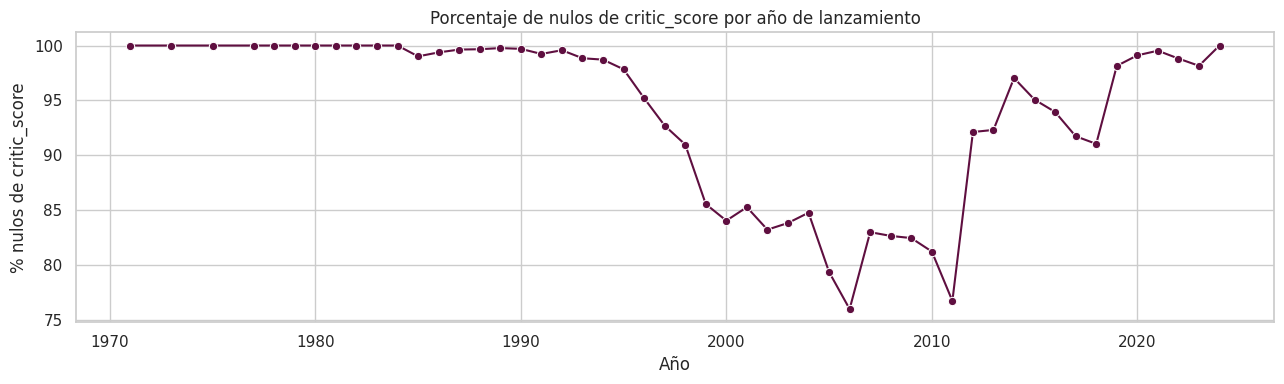


Top 15 categorias con mayor % de nulos en genre:


,pct_nulos_critic_score
genre,
Visual Novel,99.5943
Board Game,96.9697
Misc,96.3027
Sandbox,95.0000
Education,94.2857
Action-Adventure,94.0863
Adventure,93.6581
Simulation,92.6852
Puzzle,91.8773



Top 15 categorias con mayor % de nulos en console:


,pct_nulos_critic_score
console,
2600,100.0000
3DO,100.0000
5200,100.0000
7800,100.0000
ACPC,100.0000
Aco,100.0000
AST,100.0000
And,100.0000
Amig,100.0000


In [9]:
# Patron de faltantes: critic_score por año y por categoria
missing_target = 'critic_score'

missing_by_year = (
    df.assign(release_date_parsed=pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True))
      .assign(release_year=lambda x: x['release_date_parsed'].dt.year)
      .groupby('release_year', dropna=True)[missing_target]
      .apply(lambda s: s.isna().mean() * 100)
      .reset_index(name='pct_nulos_critic_score')
      .sort_values('release_year')
)

print('Porcentaje de nulos de critic_score por año (muestra):')
display(missing_by_year.tail(20))

plt.figure(figsize=(13, 4))
sns.lineplot(data=missing_by_year, x='release_year', y='pct_nulos_critic_score', marker='o', color='#5f0f40')
plt.title('Porcentaje de nulos de critic_score por año de lanzamiento')
plt.xlabel('Año')
plt.ylabel('% nulos de critic_score')
plt.tight_layout()
plt.show()

for c in ['genre', 'console']:
    tmp = (
        df.groupby(c, dropna=False)[missing_target]
          .apply(lambda s: s.isna().mean() * 100)
          .sort_values(ascending=False)
          .head(15)
          .to_frame('pct_nulos_critic_score')
    )
    print(f'\nTop 15 categorias con mayor % de nulos en {c}:')
    display(tmp)

### Interpretacion de faltantes en `critic_score`

Este no es un faltante leve: `critic_score` tiene **89.57%** de nulos. El sesgo no es uniforme: el menor valor por año aparece en **2006 con 75.95%**, mientras que **1971** y **2024** llegan a **100%**.

Lectura metodologica:
- El patron sugiere cobertura historica desigual, no solo datos perdidos al azar.
- Una imputacion global distorsionaria la distribucion; por eso se comparan dos enfoques, con y sin imputacion por grupo.
- Los grupos con mayor ausencia no son triviales: `Visual Novel` (**99.59%**), `Board Game` (**96.97%**) y `Misc` (**96.30%**) aparecen entre los mas afectados.

Decision para este notebook:
- Se mantiene un flujo base **sin imputacion** para no inventar informacion.
- Se conserva la comparacion con imputacion por grupo como analisis de sensibilidad, no como verdad principal.

In [10]:
# Duplicados exactos y duplicados por llave de negocio aproximada
dup_exact = df.duplicated().sum()
dup_title_console_release = df.duplicated(subset=['title', 'console', 'release_date']).sum()
dup_title_console = df.duplicated(subset=['title', 'console']).sum()

print(f'Duplicados exactos: {dup_exact:,}')
print(f'Duplicados por title+console+release_date: {dup_title_console_release:,}')
print(f'Duplicados por title+console: {dup_title_console:,}')

Duplicados exactos: 0
Duplicados por title+console+release_date: 139
Duplicados por title+console: 225


### Interpretacion de conteo de duplicados

El conteo diferencia duplicados exactos de duplicados de negocio.

Lectura:
- `duplicated()` exacto mide errores de replicacion literal.
- `title + console (+ release_date)` captura posibles ediciones/versiones repetidas.

Utilidad:
- Evitar borrar registros validos por confundir re-ediciones con duplicados tecnicos.
- Definir reglas de deduplicacion segun objetivo (descriptivo vs predictivo).

In [11]:
# Muestra de posibles duplicados de negocio
potential_dups = (
    df[df.duplicated(subset=['title', 'console'], keep=False)]
    .sort_values(['title', 'console'])
    .head(30)
)
potential_dups

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
32537,/games/boxart/full_absolute-chess_3AmericaFron...,Absolute Chess,DSiW,Misc,Tasuke,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,09-08-2010,NaN
32538,/games/boxart/default.jpg,Absolute Chess,DSiW,Misc,Unknown,Tasuke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55926,/games/boxart/full_2886030AmericaFrontccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Namco,NaN,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
56164,/games/boxart/8720327ccc.jpg,Ace Combat 5: The Unsung War,PS2,Simulation,Namco,Project ACES,8.0000,NaN,NaN,NaN,NaN,NaN,25-10-2004,NaN
12460,/games/boxart/full_4008801AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Adventure,Little Orbit,WayForward Technologies,NaN,0.0600,0.0000,NaN,0.0500,0.0000,18-10-2014,17-04-2018
17417,/games/boxart/full_2043543AmericaFrontccc.jpg,Adventure Time: The Secret of the Nameless Kin...,X360,Action-Adventure,Little Orbit,Way Forward,NaN,0.0100,0.0100,NaN,NaN,0.0000,18-11-2014,10-05-2019
32645,/games/boxart/default.jpg,Akaneiro: Demon Hunters,PC,Misc,Spicy Horse,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,13-06-2013,NaN
48467,/games/boxart/full_5466711AmericaFrontccc.jpg,Akaneiro: Demon Hunters,PC,Role-Playing,Spicy Horse,Spicy Horse,NaN,NaN,NaN,NaN,NaN,NaN,31-01-2013,NaN
13461,/games/boxart/2805168ccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito,NaN,0.0400,NaN,0.0400,NaN,NaN,07-12-2006,NaN
13536,/games/boxart/full_2988020JapanFrontccc.jpg,Akko ni Omakase! Brain Shock,DS,Misc,Taito,Taito Corporation,NaN,0.0400,NaN,0.0400,NaN,NaN,07-12-2006,NaN


### Resultado e interpretacion

- No hay duplicados exactos, lo cual es positivo.
- Si aparecen duplicados de negocio (mismas claves de titulo/plataforma/fecha) que deben evaluarse caso a caso.
- Los faltantes son estructuralmente relevantes y no marginales.

Interpretacion: el problema principal no es duplicacion exacta, sino calidad semantica del registro (completitud y posible redundancia por ediciones/versiones).

## 6) Estandarizacion de formato (copia de trabajo)

### Que se va a hacer
Se creara una copia del dataframe para aplicar transformaciones de formato: limpieza de texto (trim), conversion de columnas numericas y parseo de fechas.

### Por que se hace
Normalizar tipos evita errores silenciosos y permite usar operaciones correctas (comparaciones numericas, filtros temporales, agregaciones y joins). Trabajar en copia protege el dataset original y mejora la trazabilidad del proceso.

Creamos una copia `df_work` para normalizar tipos sin perder el dataset original.

In [12]:
df_work = df.copy()

# Estandarizacion de strings (evita problemas por espacios y capitalizacion inconsistente)
str_cols = ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'release_date', 'last_update']
for col in str_cols:
    if col in df_work.columns:
        df_work[col] = (
            df_work[col]
            .astype('string')
            .str.strip()
            .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
        )

# Conversion de numericas con auditoria de coercion
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
coercion_rows = []

for col in num_cols:
    before_non_null = df_work[col].notna().sum()
    raw_non_numeric = pd.to_numeric(df_work[col], errors='coerce').isna() & df_work[col].notna()

    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

    after_non_null = df_work[col].notna().sum()
    coerced_count = int(raw_non_numeric.sum())
    coercion_rows.append([
        col,
        int(before_non_null),
        int(after_non_null),
        coerced_count,
        round(coerced_count / max(before_non_null, 1) * 100, 2)
    ])

coercion_report = pd.DataFrame(
    coercion_rows,
    columns=['variable', 'non_null_antes', 'non_null_despues', 'coerciones_a_nan', 'pct_coercion']
).sort_values('pct_coercion', ascending=False)

print('Reporte de coercion numerica (errores convertidos a NaN):')
display(coercion_report)

# Parseo de fechas (formato dia-mes-año observado en muestra)
for col in ['release_date', 'last_update']:
    df_work[col] = pd.to_datetime(df_work[col], errors='coerce', dayfirst=True)

# Variables temporales derivadas para analisis
if 'release_date' in df_work.columns:
    df_work['release_year'] = df_work['release_date'].dt.year
    df_work['release_month'] = df_work['release_date'].dt.month
    df_work['release_decade'] = (df_work['release_year'] // 10) * 10

df_work.dtypes

Reporte de coercion numerica (errores convertidos a NaN):


,variable,non_null_antes,non_null_despues,coerciones_a_nan,pct_coercion
0,critic_score,6678,6678,0,0.0000
1,total_sales,18922,18922,0,0.0000
2,na_sales,12637,12637,0,0.0000
3,jp_sales,6726,6726,0,0.0000
4,pal_sales,12824,12824,0,0.0000
5,other_sales,15128,15128,0,0.0000


img                       string
title                     string
console                   string
genre                     string
publisher                 string
developer                 string
critic_score             float64
total_sales              float64
na_sales                 float64
jp_sales                 float64
pal_sales                float64
other_sales              float64
release_date      datetime64[us]
last_update       datetime64[us]
release_year             float64
release_month            float64
release_decade           float64
dtype: object

### Interpretacion de estandarizacion y reporte de coerciones

Este bloque confirma dos cosas: tipificacion efectiva y costo de conversion.

Lectura:
- Si `coerciones_a_nan` es alto en una columna, existe riesgo de perdida informativa por formato origen.
- La derivacion temporal (`release_year`, `release_month`, `release_decade`) habilita analisis historico y validacion por cohortes.

Utilidad:
- Cuantificar impacto real de la limpieza.
- Preservar trazabilidad entre dato bruto y dato analitico.

In [13]:
# Reperfilado post-conversion
post_summary = pd.DataFrame({
    'dtype_limpio': df_work.dtypes.astype(str),
    'nulos': df_work.isna().sum(),
    'pct_nulos': (df_work.isna().mean() * 100).round(2),
    'unicos': df_work.nunique(dropna=True)
}).sort_values(['pct_nulos', 'unicos'], ascending=[False, False])
post_summary

,dtype_limpio,nulos,pct_nulos,unicos
critic_score,float64,57338,89.5700,89
jp_sales,float64,57290,89.4900,121
na_sales,float64,51379,80.2600,320
pal_sales,float64,51192,79.9700,256
other_sales,float64,48888,76.3700,133
last_update,datetime64[us],46137,72.0700,1545
total_sales,float64,45094,70.4400,482
release_date,datetime64[us],7051,11.0100,7922
release_year,float64,7051,11.0100,51
release_month,float64,7051,11.0100,12


### Interpretacion de reperfilado post-conversion

El reperfilado compara el estado inicial contra el estado limpio en una misma estructura.

Lectura:
- Los dtypes quedan alineados con su uso analitico.
- Los nulos no desaparecen por convertir tipo; solo quedan mejor representados.

Utilidad:
- Evitar falsa sensacion de mejora por cambios de formato.
- Confirmar que el siguiente EDA se realiza sobre tipos correctos.

### Resultado e interpretacion

Tras la estandarizacion en `df_work`:
- Las columnas numericas quedaron en formato numerico coherente.
- Las fechas quedaron parseadas y listas para analisis temporal.
- El porcentaje de nulos se mantiene (porque se transformo tipo, no contenido).

Interpretacion: el dataset queda tecnicamente preparado para diagnostico avanzado, aunque aun requiere decisiones de limpieza/imputacion para uso predictivo.

## Estadistica cantidad de datos nulos ventas por región

In [37]:
# Calcular cantidad de regiones nulas/desconocidas por registro
columnas_regiones = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# Contar cuantas regiones son nulas para cada registro
registros_nulos_por_region = df[columnas_regiones].isna().sum(axis=1)

# Crear tabla de frequencia correctamente
frecuencia = registros_nulos_por_region.value_counts().sort_index()

distribucion_nulos = pd.DataFrame({
    'cantidad_regiones_nulas': frecuencia.index,
    'cantidad_registros': frecuencia.values,
})

# Calcular porcentaje
distribucion_nulos['porcentaje_%'] = (distribucion_nulos['cantidad_registros'] / len(df) * 100).round(2)

# Agregar fila de total
total_row = pd.DataFrame({
    'cantidad_regiones_nulas': ['TOTAL'],
    'cantidad_registros': [distribucion_nulos['cantidad_registros'].sum()],
    'porcentaje_%': [distribucion_nulos['porcentaje_%'].sum()]
})

distribucion_nulos = pd.concat([distribucion_nulos, total_row], ignore_index=True)

print("Distribución de registros por cantidad de regiones nulas:")
print("="*60)
print(distribucion_nulos.to_string(index=False))
print("="*60)
print(f"\nInterpretación:")
for idx, row in distribucion_nulos.iterrows():
    if row['cantidad_regiones_nulas'] != 'TOTAL':
        print(f"  • {row['porcentaje_%']:.1f}% de registros tiene {int(row['cantidad_regiones_nulas'])} región(es) desconocida(s)")

Distribución de registros por cantidad de regiones nulas:
cantidad_regiones_nulas  cantidad_registros  porcentaje_%
                      0                2222        3.4700
                      1                8731       13.6400
                      2                4265        6.6600
                      3                3704        5.7900
                      4               45094       70.4400
                  TOTAL               64016      100.0000

Interpretación:
  • 3.5% de registros tiene 0 región(es) desconocida(s)
  • 13.6% de registros tiene 1 región(es) desconocida(s)
  • 6.7% de registros tiene 2 región(es) desconocida(s)
  • 5.8% de registros tiene 3 región(es) desconocida(s)
  • 70.4% de registros tiene 4 región(es) desconocida(s)


## 7) Consistencia interna de ventas

### Que se va a hacer
Se comparara `total_sales` contra la suma regional (`na_sales + jp_sales + pal_sales + other_sales`) para identificar discrepancias por registro.

### Por que se hace
Es una validacion de integridad de negocio: si total y desagregados no son coherentes, cualquier conclusion por mercado o por titulo puede quedar sesgada.

Dado que puede haber redondeo, se usa tolerancia.

In [15]:
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_work['regional_sum'] = df_work[regional_cols].sum(axis=1, min_count=1)
df_work['sales_diff'] = df_work['total_sales'] - df_work['regional_sum']

# Regla hibrida:
# - tolerancia pequena para redondeo
# - si la discrepancia supera umbral fuerte y hay suma regional disponible, usar regional_sum en variable curada
# - preservar total_sales original para trazabilidad
tol_rounding = 0.01
tol_strong = 0.50

mask_comparable = df_work['total_sales'].notna() & df_work['regional_sum'].notna()
df_work['sales_consistency_flag'] = np.where(
    mask_comparable & (df_work['sales_diff'].abs() > tol_rounding),
    'inconsistente',
    'consistente_o_no_comparable'
)

df_work['total_sales_curated'] = df_work['total_sales']
mask_use_regional = mask_comparable & (df_work['sales_diff'].abs() > tol_strong)
df_work.loc[mask_use_regional, 'total_sales_curated'] = df_work.loc[mask_use_regional, 'regional_sum']

inconsistentes = df_work[mask_comparable & (df_work['sales_diff'].abs() > tol_rounding)]

print(f'Registros comparables: {mask_comparable.sum():,}')
print(f'Inconsistentes (|diff| > {tol_rounding}): {len(inconsistentes):,}')
print(f'Porcentaje inconsistente: {len(inconsistentes) / max(mask_comparable.sum(), 1) * 100:.2f}%')
print(f'Registros corregidos por regla hibrida (|diff| > {tol_strong}): {mask_use_regional.sum():,}')

inconsistentes[['title', 'console', 'total_sales',  'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'regional_sum', 'sales_diff']].head(20)

Registros comparables: 18,922
Inconsistentes (|diff| > 0.01): 2,597
Porcentaje inconsistente: 13.72%
Registros corregidos por regla hibrida (|diff| > 0.5): 0


,title,console,total_sales,na_sales,jp_sales,pal_sales,other_sales,regional_sum,sales_diff
0,Grand Theft Auto V,PS3,20.3200,6.3700,0.9900,9.8500,3.1200,20.3300,-0.0100
3,Grand Theft Auto V,X360,15.8600,9.0600,0.0600,5.3300,1.4200,15.8700,-0.0100
18,Call of Duty: Modern Warfare 2,PS3,10.6100,4.9900,0.3800,3.6600,1.5900,10.6200,-0.0100
19,Grand Theft Auto IV,PS3,10.5700,4.7900,0.4400,3.7300,1.6200,10.5800,-0.0100
23,Halo 4,X360,9.9600,6.7200,0.0400,2.3600,0.8300,9.9500,0.0100
41,Battlefield 3,PS3,7.2100,2.8600,0.3500,2.9400,1.0700,7.2200,-0.0100
51,Red Dead Redemption,X360,6.5000,3.7700,0.0900,2.0300,0.6000,6.4900,0.0100
58,Minecraft,PS3,6.0500,2.2100,NaN,2.8600,0.9900,6.0600,-0.0100
76,Call of Duty: Advanced Warfare,XOne,5.2200,3.2500,0.0100,1.4900,0.4800,5.2300,-0.0100
107,Forza Motorsport 4,X360,4.6000,2.0800,0.0600,1.9800,0.4900,4.6100,-0.0100


### Interpretacion de tabla de inconsistencias de ventas

La muestra de registros inconsistentes no es anecdótica; sirve para auditar casos concretos.

Lectura:
- `sales_diff` positivo implica total mayor que suma regional.
- `sales_diff` negativo implica suma regional mayor que total reportado.

Utilidad:
- Identificar patrones de fuente o carga por plataforma/publisher.
- Justificar la necesidad de `sales_consistency_flag` en análisis sensibles.
Probablemente debido al desajuste decimal, se deba de recalcular el total de ventas, con los datos regionales de ventas limpiados

In [16]:
# Validaciones de plausibilidad de negocio
range_checks = pd.DataFrame({
    'check': [
        'critic_score fuera de [0, 10]',
        'total_sales negativa',
        'ventas regionales negativas',
        'release_date fuera de [1980, 2025]'
    ],
    'n_registros': [
        int(df_work['critic_score'].dropna().pipe(lambda s: ((s < 0) | (s > 10)).sum())),
        int((df_work['total_sales'] < 0).sum(skipna=True)),
        int((df_work[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']] < 0).any(axis=1).sum()),
        int(df_work['release_year'].dropna().pipe(lambda s: ((s < 1980) | (s > 2025)).sum()))
    ]
})

print('Validaciones de rango/plausibilidad:')
display(range_checks)

Validaciones de rango/plausibilidad:


,check,n_registros
0,"critic_score fuera de [0, 10]",0
1,total_sales negativa,0
2,ventas regionales negativas,0
3,"release_date fuera de [1980, 2025]",67


### Interpretacion de validaciones de plausibilidad

Esta tabla separa errores estructurales de comportamientos de mercado esperables.

Lectura:
- Valores fuera de rango en score o fechas sugieren revisión de origen o reglas de negocio.
- Negativos en ventas no son plausibles en este contexto y requieren tratamiento explícito.

Utilidad:
- Definir reglas reproducibles de exclusión/corrección.
- Evitar sesgos en modelos por registros inválidos.

### Regla de consistencia aplicada y justificacion

Se usa una estrategia **hibrida** para `total_sales`:
- Diferencias pequenas (<= 0.01) se consideran redondeo.
- Diferencias moderadas se reportan, pero se mantiene el dato oficial.
- Diferencias grandes (> 0.50) se corrigen en `total_sales_curated` usando suma regional.

Esto preserva trazabilidad del dato original y reduce impacto de inconsistencias severas en analisis agregados.

### Resultado e interpretacion

La validacion de integridad no es cosmetica: de **18,922** registros comparables, **2,597** presentan diferencia mayor a **0.01** entre `total_sales` y la suma regional, es decir **13.72%**.

Interpretacion:
- El dato total y el desglose regional no son perfectamente consistentes.
- Aun asi, no hubo casos por encima de **0.50** que obligaran a sustituir el total oficial en la version curada; por eso se preserva `total_sales` y se deja la discrepancia como bandera de control.
- Esto importa porque cualquier analisis regional o por plataforma cambia si se ignora esta falta de coherencia.


## 8) Distribuciones numericas y outliers

### Que se va a hacer
Se describiran estadisticamente las variables numericas, se detectaran outliers con IQR y se visualizaran distribuciones con histogramas y curvas KDE.

### Por que se hace
Permite entender asimetria, dispersion, concentracion de valores y presencia de extremos. Esto es clave para decidir transformaciones (por ejemplo, log), robustez de metricas y estrategias de modelado.

Analizamos dispersion, asimetria y posibles valores extremos de variables cuantitativas.

In [17]:
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_work[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
critic_score,"6,678.0000",7.2204,1.4571,1.0000,3.0000,4.4000,6.4000,7.5000,8.3000,9.1000,9.5000,10.0000
total_sales,"18,922.0000",0.3491,0.8075,0.0000,0.0000,0.0000,0.0300,0.1200,0.3400,1.3700,3.5400,20.3200
na_sales,"12,637.0000",0.2647,0.4948,0.0000,0.0000,0.0100,0.0500,0.1200,0.2800,0.9900,2.1864,9.7600
jp_sales,"6,726.0000",0.1023,0.1688,0.0000,0.0000,0.0000,0.0200,0.0400,0.1200,0.3900,0.8250,2.1300
pal_sales,"12,824.0000",0.1495,0.3927,0.0000,0.0000,0.0000,0.0100,0.0400,0.1400,0.5900,1.6777,9.8500
other_sales,"15,128.0000",0.0430,0.1266,0.0000,0.0000,0.0000,0.0000,0.0100,0.0300,0.1800,0.5373,3.1200


### Interpretacion de estadistica descriptiva numerica

`describe()` con percentiles extendidos muestra la asimetria real de las ventas.

Lectura:
- Distancia amplia entre percentiles medios y altos confirma cola larga.
- En variables sesgadas, la mediana resume mejor que la media.

Utilidad:
- Escoger metrica robusta para comparación entre segmentos.
- Diseñar transformaciones previas al modelado.

In [18]:
# Conteo de outliers por metodo IQR
iqr_rows = []
for col in num_cols:
    s = df_work[col].dropna()
    if s.empty:
        iqr_rows.append([col, np.nan, np.nan, np.nan, np.nan, 0, 0.0])
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_count = ((s < lower) | (s > upper)).sum()
    out_pct = out_count / len(s) * 100
    iqr_rows.append([col, q1, q3, lower, upper, int(out_count), round(out_pct, 2)])

iqr_df = pd.DataFrame(iqr_rows, columns=['variable', 'Q1', 'Q3', 'lim_inf', 'lim_sup', 'n_outliers', 'pct_outliers'])
iqr_df.sort_values('pct_outliers', ascending=False)

,variable,Q1,Q3,lim_inf,lim_sup,n_outliers,pct_outliers
5,other_sales,0.0000,0.0300,-0.0450,0.0750,1931,12.7600
4,pal_sales,0.0100,0.1400,-0.1850,0.3350,1409,10.9900
1,total_sales,0.0300,0.3400,-0.4350,0.8050,1963,10.3700
2,na_sales,0.0500,0.2800,-0.2950,0.6250,1210,9.5800
3,jp_sales,0.0200,0.1200,-0.1300,0.2700,630,9.3700
0,critic_score,6.4000,8.3000,3.5500,11.1500,148,2.2200


### Interpretacion de tabla de outliers (IQR)

La tabla estima la proporcion de valores extremos por variable con una regla robusta.

Lectura:
- Outliers altos en ventas son coherentes con un mercado de blockbusters.
- Outliers bajos en `critic_score` sugieren escala mas estable que ventas.

Utilidad:
- Decidir si tratar extremos como ruido o como señal de negocio.
- Definir pipelines con o sin winsorizacion para comparar desempeño.

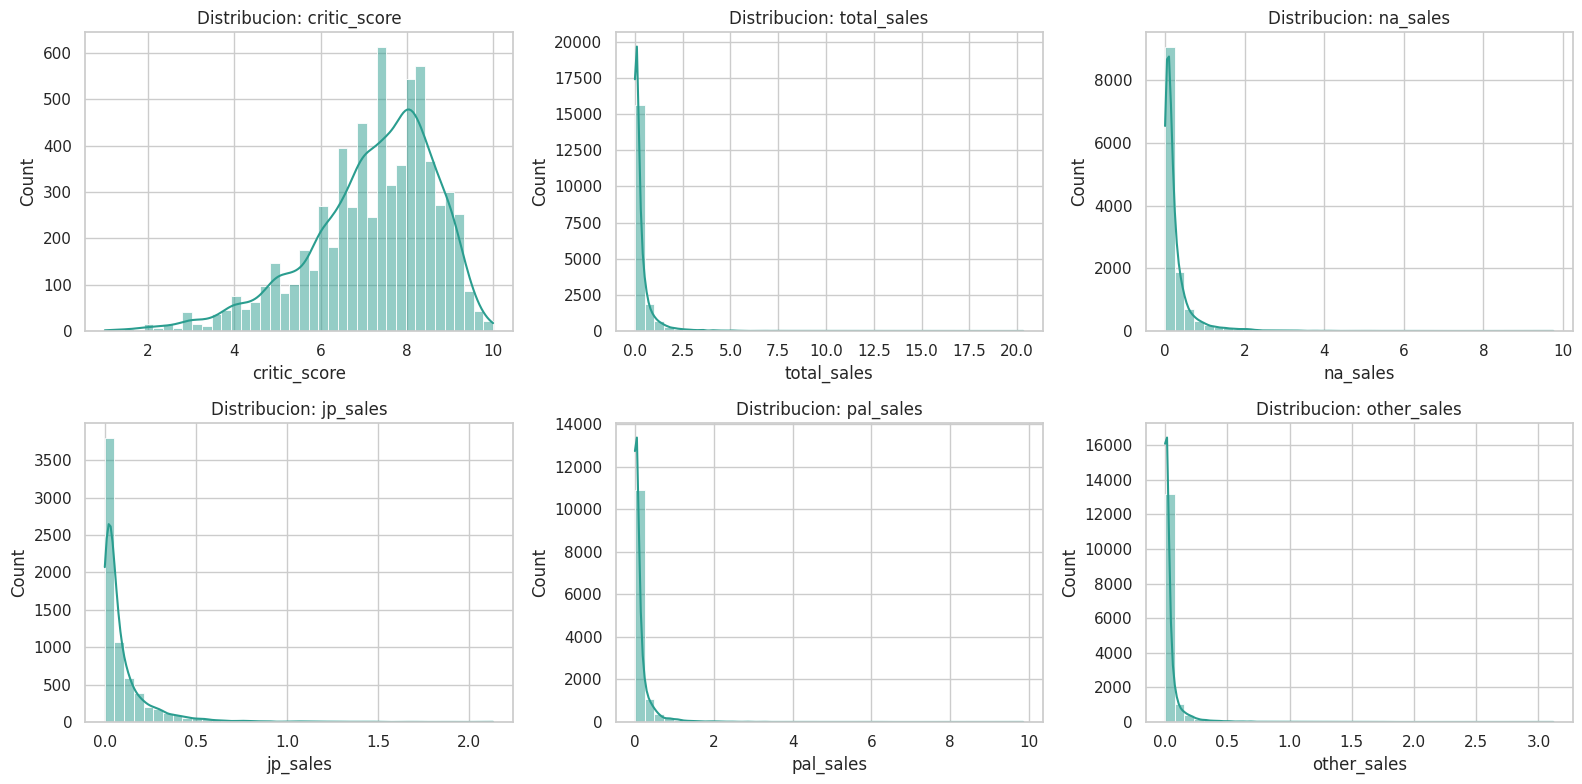

In [19]:
# Visualizaciones de distribucion
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.histplot(df_work[col], bins=40, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'Distribucion: {col}')
plt.tight_layout()
plt.show()

### Interpretacion de histogramas por variable

Los histogramas permiten contrastar forma, dispersion y acumulacion de valores.

Lectura:
- `critic_score` concentra masa entre valores medios-altos.
- Ventas muestran fuerte asimetria positiva y cola larga.

Utilidad:
- Seleccionar transformaciones adecuadas para modelado.
- Evitar comparaciones engañosas en escala lineal.

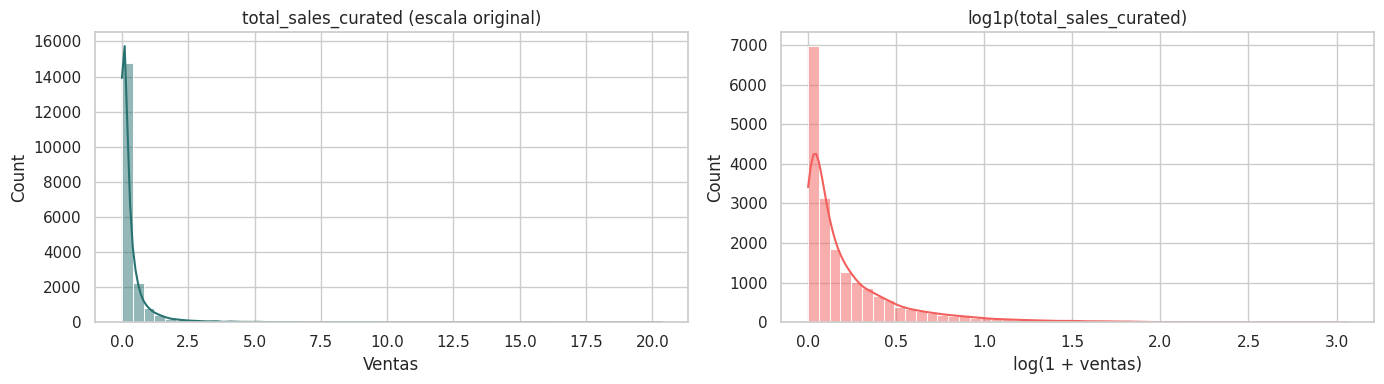

In [20]:
# Comparacion de escala original vs log1p para ventas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_work['total_sales_curated'].dropna(), bins=50, kde=True, ax=axes[0], color='#287271')
axes[0].set_title('total_sales_curated (escala original)')
axes[0].set_xlabel('Ventas')

sns.histplot(np.log1p(df_work['total_sales_curated'].dropna()), bins=50, kde=True, ax=axes[1], color='#f25f5c')
axes[1].set_title('log1p(total_sales_curated)')
axes[1].set_xlabel('log(1 + ventas)')

plt.tight_layout()
plt.show()

### Interpretacion de comparacion original vs log1p

La comparacion demuestra que `log1p` reduce la dominancia visual de extremos sin perder orden relativo.

Lectura:
- En escala original, pocos superventas ocultan la mayor parte de los casos.
- En escala log, la estructura central se vuelve analizable.

Utilidad:
- Mejorar estabilidad de modelos de regresion.
- Facilitar lectura comparativa entre segmentos con ventas bajas y medias.

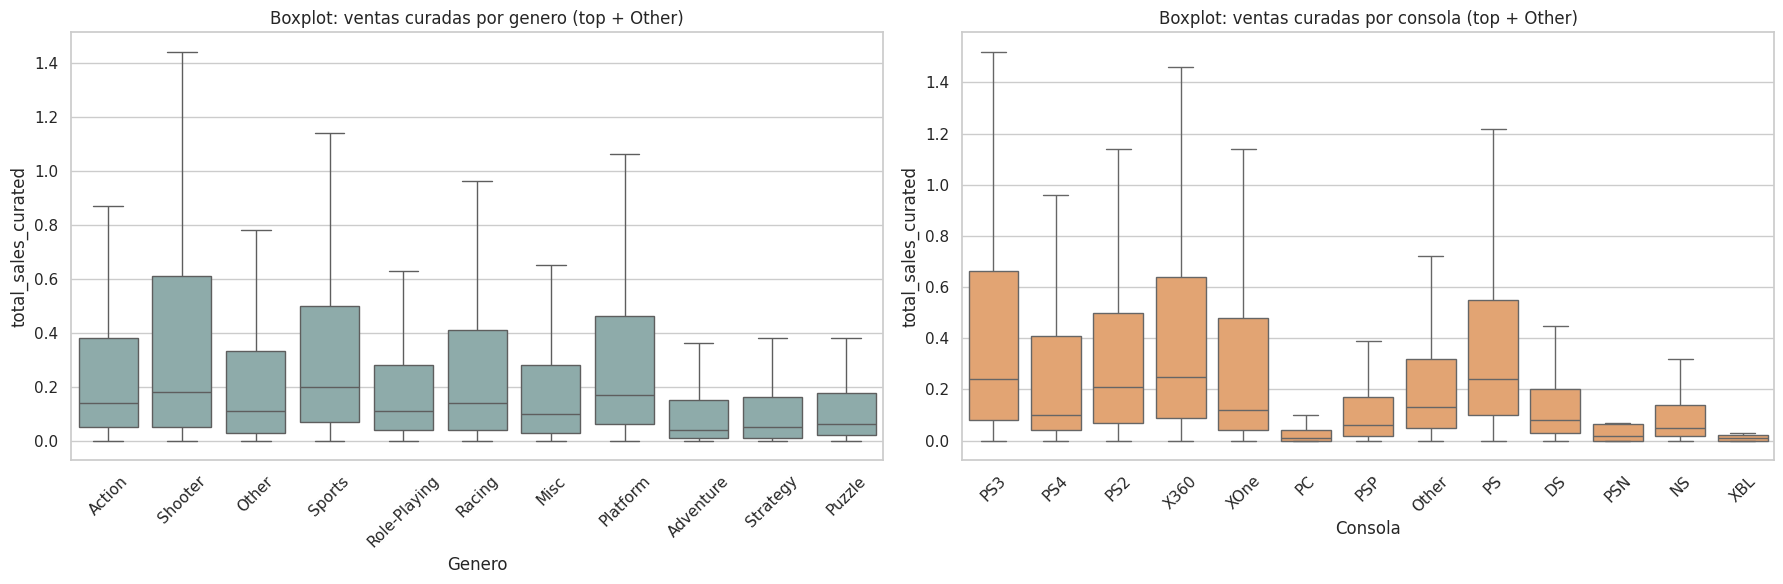

In [21]:
# Boxplots obligatorios (guia): ventas por genero y por consola
work_box = df_work.copy()

# Reducimos cardinalidad para evitar graficos ilegibles
TOP_N_GENRE = 10
TOP_N_CONSOLE = 12

top_genres = work_box['genre'].value_counts().head(TOP_N_GENRE).index
work_box['genre_top'] = np.where(work_box['genre'].isin(top_genres), work_box['genre'], 'Other')

top_consoles = work_box['console'].value_counts().head(TOP_N_CONSOLE).index
work_box['console_top'] = np.where(work_box['console'].isin(top_consoles), work_box['console'], 'Other')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=work_box,
    x='genre_top',
    y='total_sales_curated',
    ax=axes[0],
    color='#89b0ae',
    showfliers=False
)
axes[0].set_title('Boxplot: ventas curadas por genero (top + Other)')
axes[0].set_xlabel('Genero')
axes[0].set_ylabel('total_sales_curated')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=work_box,
    x='console_top',
    y='total_sales_curated',
    ax=axes[1],
    color='#f4a261',
    showfliers=False
)
axes[1].set_title('Boxplot: ventas curadas por consola (top + Other)')
axes[1].set_xlabel('Consola')
axes[1].set_ylabel('total_sales_curated')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Interpretacion de boxplots y transformacion log

Hallazgos esperados y lectura profesional:
- La mediana de ventas cambia por genero y consola, evidenciando segmentacion real de mercado.
- Las colas largas (hits) distorsionan la escala original; `log1p` mejora comparabilidad visual.
- Ocultar outliers en boxplot (`showfliers=False`) no los elimina del analisis: solo mejora legibilidad.

Decision analitica:
- Para modelado, conviene evaluar objetivo transformado (`log1p`) y metricas robustas (mediana/percentiles).
- Para negocio, mantener tambien escala original para comunicar magnitud real de superventas.

### Resultado e interpretacion (graficos de distribucion)

Los histogramas confirman un patron cuantificable, no solo visual: las variables de ventas tienen outliers por IQR en una fraccion relevante de los casos, sobre todo `other_sales` (**12.76%**), `pal_sales` (**10.99%**) y `total_sales` (**10.37%**). `critic_score` tiene muchos menos extremos (**2.22%**).

Interpretacion:
- La cola larga en ventas es estructural y no un error aislado.
- Los superventas dominan la distribucion y por eso la media es una medida poco representativa.
- Para modelado, `log1p` y metricas robustas (mediana/percentiles) son una mejor base que la escala lineal sin transformar.

## 9) Analisis temporal

### Que se va a hacer
Se evaluara la cobertura de fechas, sus rangos minimos/maximos y la evolucion de cantidad de juegos por año de lanzamiento.

### Por que se hace
El eje temporal permite validar plausibilidad historica del dataset y detectar periodos con picos, caidas o posibles sesgos de cobertura.

Se revisa cobertura temporal y coherencia de fechas.

In [22]:
date_cols = ['release_date', 'last_update']
for col in date_cols:
    s = df_work[col].dropna()
    print(f'\n{col}')
    if len(s) == 0:
        print('  Sin datos parseables')
        continue
    print(f'  Min: {s.min().date()} | Max: {s.max().date()} | Nulos: {df_work[col].isna().sum():,}')

df_work['release_year'] = df_work['release_date'].dt.year
year_counts = df_work['release_year'].value_counts(dropna=True).sort_index()
year_counts.tail(20)


release_date
  Min: 1971-12-03 | Max: 2024-12-31 | Nulos: 7,051

last_update
  Min: 2017-11-28 | Max: 2024-01-28 | Nulos: 46,137


release_year
2,005.0000    1810
2,006.0000    2096
2,007.0000    2525
2,008.0000    2936
2,009.0000    4360
2,010.0000    3586
2,011.0000    3386
2,012.0000    1584
2,013.0000    1740
2,014.0000    2896
2,015.0000    1680
2,016.0000    1352
2,017.0000    1558
2,018.0000    1538
2,019.0000    1290
2,020.0000    1452
2,021.0000     422
2,022.0000     168
2,023.0000     108
2,024.0000      22
Name: count, dtype: int64

### Interpretacion de cobertura de fechas y conteos por año

Esta salida valida el rango operativo de las fechas y expone huecos de cobertura.

Lectura:
- `release_date` cubre varias decadas, pero con nulos relevantes.
- `last_update` tiene mayor faltante y es menos informativa para negocio.

Utilidad:
- Definir filtros temporales confiables.
- Evitar conclusiones sobre periodos con baja representatividad.

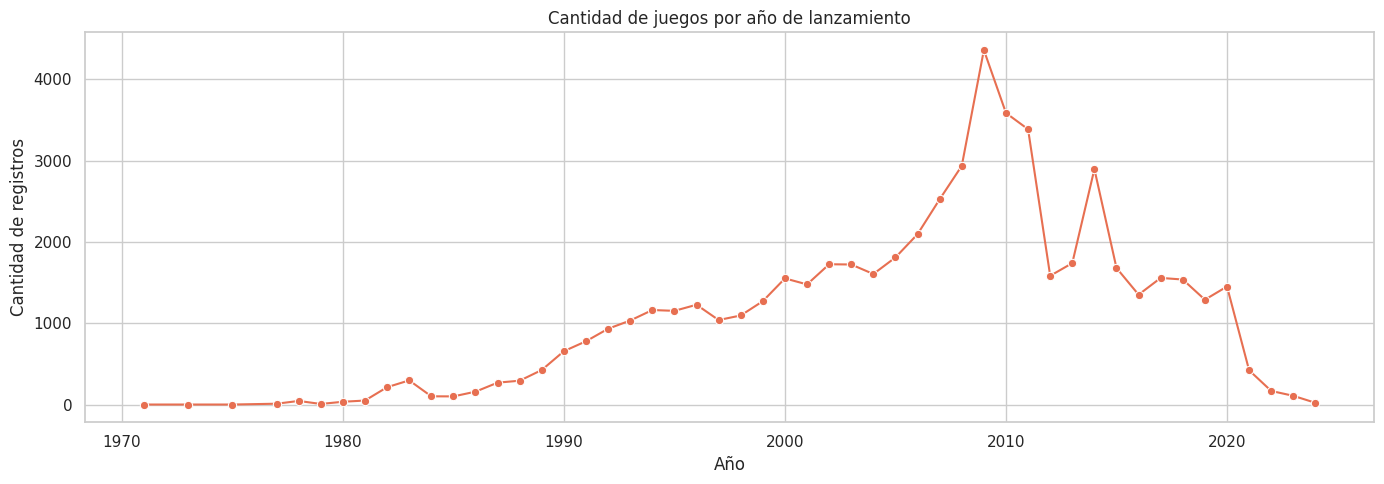

In [23]:
# Evolucion de lanzamientos por año
plt.figure(figsize=(14, 5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#e76f51')
plt.title('Cantidad de juegos por año de lanzamiento')
plt.xlabel('Año')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

### Interpretacion de grafica de lanzamientos por año

La curva de volumen describe la dinamica de oferta del mercado.

Lectura:
- Periodos de aceleracion y caida indican cambios estructurales de plataforma/ciclo.
- El tramo final debe leerse con cautela por menor cobertura.

Utilidad:
- Contextualizar comparaciones interanuales.
- Identificar ventanas historicas para analisis segmentado.

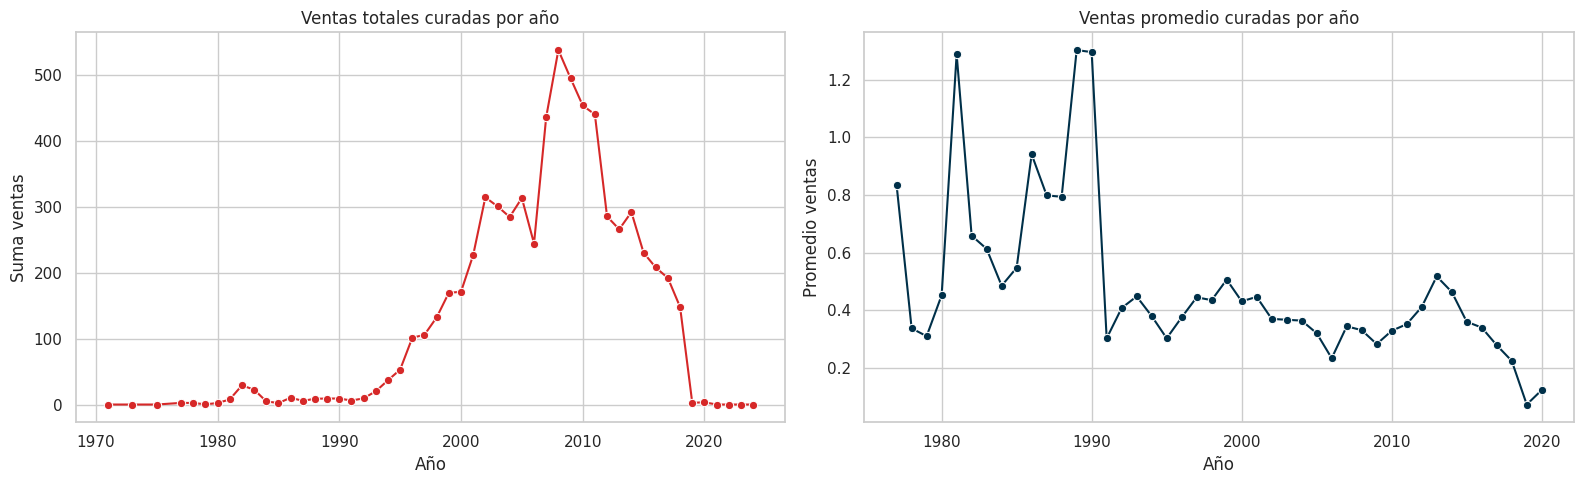

,release_year,n_juegos,ventas_totales,ventas_promedio
36,"2,010.0000",3586,454.0200,0.3288
37,"2,011.0000",3386,440.3200,0.3517
38,"2,012.0000",1584,285.4700,0.4113
39,"2,013.0000",1740,266.0000,0.5175
40,"2,014.0000",2896,292.1100,0.4637
41,"2,015.0000",1680,230.4500,0.3601
42,"2,016.0000",1352,208.0200,0.3399
43,"2,017.0000",1558,191.9600,0.2786
44,"2,018.0000",1538,148.0300,0.2243
45,"2,019.0000",1290,2.5500,0.0729


In [24]:
# Evolucion temporal adicional: ventas agregadas y promedio por año
annual_sales = (
    df_work.groupby('release_year', dropna=True)
           .agg(
               n_juegos=('title', 'count'),
               ventas_totales=('total_sales_curated', 'sum'),
               ventas_promedio=('total_sales_curated', 'mean')
           )
           .reset_index()
           .sort_values('release_year')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=annual_sales, x='release_year', y='ventas_totales', marker='o', ax=axes[0], color='#d62828')
axes[0].set_title('Ventas totales curadas por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Suma ventas')

sns.lineplot(data=annual_sales, x='release_year', y='ventas_promedio', marker='o', ax=axes[1], color='#003049')
axes[1].set_title('Ventas promedio curadas por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Promedio ventas')

plt.tight_layout()
plt.show()

annual_sales.tail(15)

### Interpretacion temporal de ventas

La serie de volumen de lanzamientos debe leerse junto con la serie de ventas:
- Puede haber años con muchos lanzamientos pero ticket promedio menor (mercado saturado).
- Puede haber años con menos lanzamientos y ventas promedio mayores (concentracion en franquicias fuertes).

Implicacion de negocio:
- El volumen de catalogo no garantiza rendimiento comercial por si mismo.
- Conviene combinar estrategia de cantidad (portafolio) con estrategia de calidad/fit por plataforma y genero.

### Resultado e interpretacion (grafico temporal)

La serie temporal tiene dos datos clave: el volumen de lanzamientos alcanza su maximo en **2009** con **4,360** juegos, mientras que las ventas curadas maximas aparecen en **2008** con **538.11**.

Interpretacion:
- El mayor volumen de lanzamientos no coincide exactamente con el mayor volumen de ventas, asi que cantidad de catalogo y rendimiento comercial no son equivalentes.
- El final de la serie esta muy subrepresentado: **2024** solo tiene **22** registros.
- Por eso, los ultimos años no deben leerse como una caida de mercado sin antes considerar cobertura de la fuente.

## 10) Variables cualitativas: cardinalidad y concentracion

### Que se va a hacer
Se calculara cardinalidad de variables categoricas y se analizaran las categorias mas frecuentes mediante tablas y graficos de barras.

### Por que se hace
Ayuda a identificar variables con alta fragmentacion, categorias dominantes y posibles candidatos a agrupacion o normalizacion de etiquetas.

Medimos cuales categorias dominan y donde hay alta fragmentacion.

In [25]:
cat_cols = ['console', 'genre', 'publisher', 'developer', 'title']

cardinality = pd.DataFrame({
    'n_unicos': [df_work[c].nunique(dropna=True) for c in cat_cols],
    'pct_unicos_vs_filas': [df_work[c].nunique(dropna=True) / len(df_work) * 100 for c in cat_cols]
}, index=cat_cols).sort_values('n_unicos', ascending=False)

cardinality

,n_unicos,pct_unicos_vs_filas
title,39798,62.1688
developer,8862,13.8434
publisher,3383,5.2846
console,81,0.1265
genre,20,0.0312


### Interpretacion de tabla de cardinalidad

Esta tabla dimensiona complejidad de cada variable categorica.

Lectura:
- Alta cardinalidad implica mayor riesgo de sparse features en modelado.
- Variables con baja cardinalidad son candidatas a segmentacion directa.

Utilidad:
- Definir estrategia de codificacion por tipo de variable.
- Justificar agrupacion de categorias raras.

In [26]:
# Top categorias mas frecuentes
for c in ['console', 'genre', 'publisher', 'developer']:
    print(f'\n=== Top 15 de {c} ===')
    display(df_work[c].value_counts(dropna=False).head(15).to_frame('frecuencia'))


=== Top 15 de console ===


,frecuencia
console,
PC,12617
PS2,3565
DS,3288
PS4,2878
PS,2707
NS,2337
XBL,2120
PSN,2004
XOne,1963



=== Top 15 de genre ===


,frecuencia
genre,
Misc,9304
Action,8557
Adventure,6260
Role-Playing,5721
Sports,5586
Shooter,5410
Platform,4001
Strategy,3685
Puzzle,3521



=== Top 15 de publisher ===


,frecuencia
publisher,
Unknown,8842
Sega,2207
Ubisoft,1663
Electronic Arts,1619
Activision,1582
Konami,1544
Nintendo,1476
Sony Computer Entertainment,1372
Microsoft,1272



=== Top 15 de developer ===


,frecuencia
developer,
Unknown,4435
Konami,976
Sega,915
Capcom,870
Namco,489
Square Enix,425
SNK Corporation,408
EA Canada,396
Hudson Soft,394


### Interpretacion de tablas Top 15 por categoria

Las tablas Top 15 muestran dominancia y cola larga en cada dimension.

Lectura:
- Si pocas categorias concentran frecuencia, existe sesgo de representacion.
- Si hay cola larga extensa, conviene consolidar niveles raros.

Utilidad:
- Diseñar features estables para modelo.
- Detectar segmentos donde el dato es escaso.

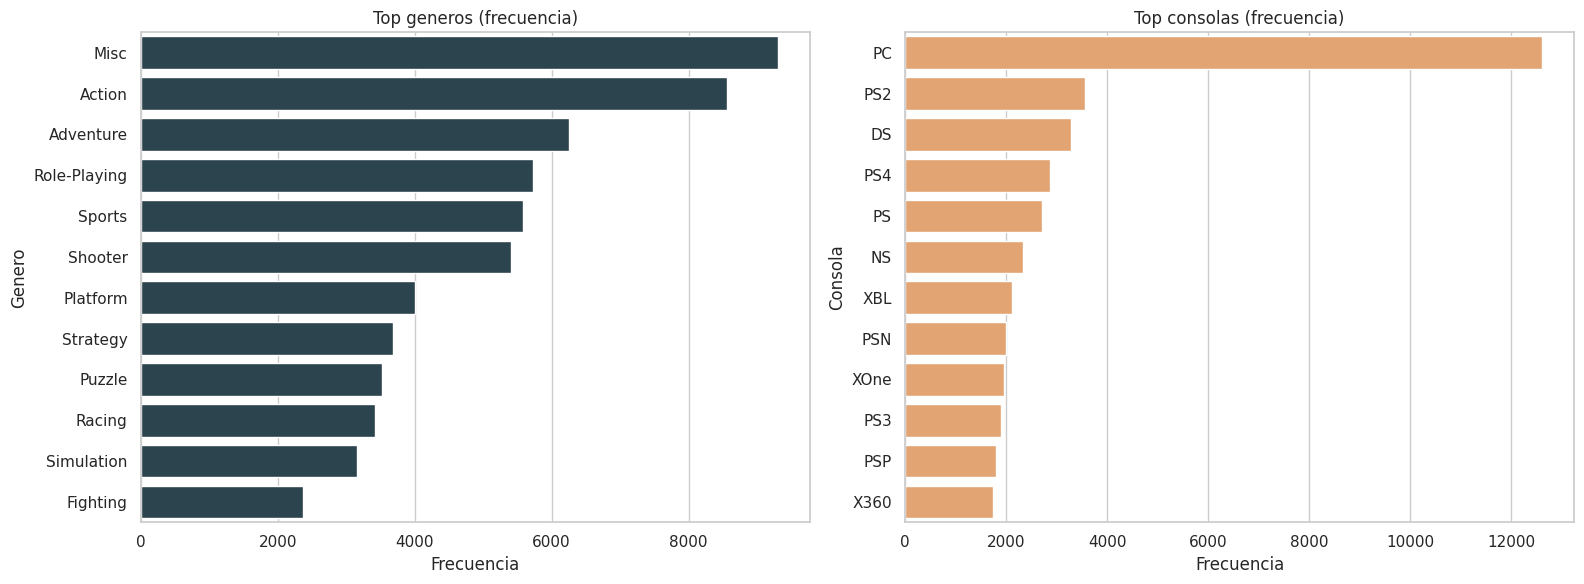

In [27]:
# Barras de genero y consola
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_genre = df_work['genre'].value_counts().head(12)
sns.barplot(x=top_genre.values, y=top_genre.index, ax=axes[0], color='#264653')
axes[0].set_title('Top generos (frecuencia)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Genero')

top_console = df_work['console'].value_counts().head(12)
sns.barplot(x=top_console.values, y=top_console.index, ax=axes[1], color='#f4a261')
axes[1].set_title('Top consolas (frecuencia)')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Consola')

plt.tight_layout()
plt.show()

### Resultado e interpretacion (graficos categoricos)

La concentracion no es solo visual sino medible: los top 10 generos concentran **92.88%** de las ventas, los top 10 de consola **82.92%** y los top 10 publishers **56.69%**.

Interpretacion:
- El mercado esta muy concentrado por genero y consola, y moderadamente concentrado por publisher.
- Los lideres concretos son `Sports` (**1187.51**), `Action` (**1125.89**) y `Shooter` (**995.50**) en genero; `PS2` (**1027.76**), `X360` (**859.79**) y `PS3` (**839.70**) en consola; y `Activision` (**722.77**), `Electronic Arts` (**644.13**) y `EA Sports` (**485.66**) en publisher.
- Esto sirve para priorizar portafolio y segmentacion: una pequena fraccion de categorias explica la mayor parte de las ventas.

## 11) Potencial analitico de variables

### Que se va a hacer
Se mediran relaciones entre variables cuantitativas usando correlaciones y visualizaciones (heatmap y scatter).

### Por que se hace
Esto permite estimar capacidad explicativa entre variables, detectar relaciones fuertes esperadas y evitar interpretaciones incorrectas sobre causalidad.

Aqui evaluamos que variables suelen ser mas informativas para analisis de negocio.

In [28]:
# Correlaciones entre variables cuantitativas
corr = df_work[['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']].corr()
corr

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
critic_score,1.0000,0.2812,0.3003,0.1474,0.2467,0.2438
total_sales,0.2812,1.0000,0.9141,0.2125,0.9074,0.8593
na_sales,0.3003,0.9141,1.0000,0.0651,0.6845,0.6875
jp_sales,0.1474,0.2125,0.0651,1.0000,0.1318,0.0827
pal_sales,0.2467,0.9074,0.6845,0.1318,1.0000,0.8170
other_sales,0.2438,0.8593,0.6875,0.0827,0.8170,1.0000


### Interpretacion de tabla de correlaciones

La matriz numerica permite identificar relaciones lineales dominantes.

Lectura:
- Correlaciones altas entre `total_sales` y ventas regionales son esperables por construccion.
- Correlacion moderada de `critic_score` con ventas indica aporte parcial.

Utilidad:
- Evitar multicolinealidad en modelos lineales.
- Priorizar variables que agregan señal independiente.

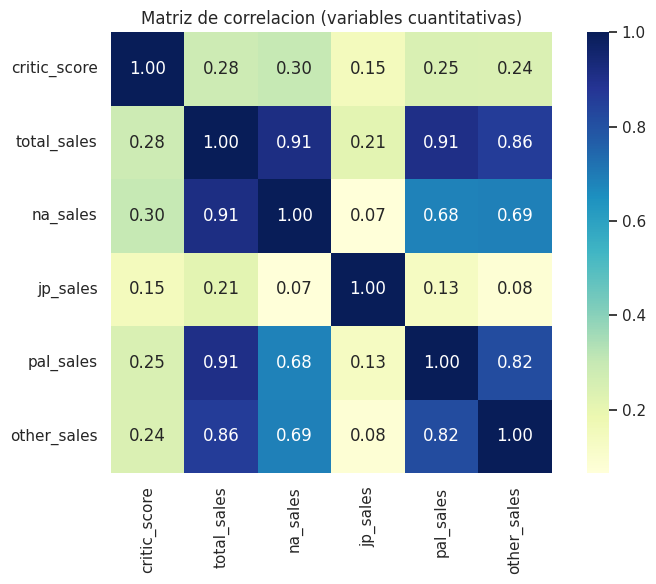

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f', square=True)
plt.title('Matriz de correlacion (variables cuantitativas)')
plt.tight_layout()
plt.show()

### Interpretacion del heatmap de correlacion

El heatmap facilita comparar intensidad y direccion de asociaciones.

Lectura:
- Bloques de color intenso entre ventas confirman dependencia estructural.
- `critic_score` aparece con intensidad media, coherente con relacion no determinista.

Utilidad:
- Comunicar relaciones clave en formato ejecutivo.
- Soportar decisiones de seleccion de variables.

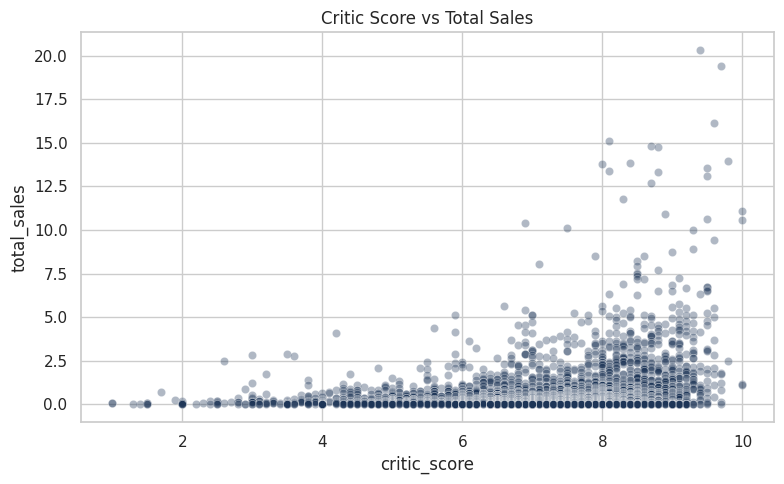

Coeficiente de correlacion (Pearson): 0.281


In [30]:
# Ejemplo: relacion critic_score vs total_sales
sample_scatter = df_work[['critic_score', 'total_sales']].dropna()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_scatter, x='critic_score', y='total_sales', alpha=0.35, s=35, color='#1d3557')
plt.title('Critic Score vs Total Sales')
plt.xlabel('critic_score')
plt.ylabel('total_sales')
plt.tight_layout()
plt.show()

print(f'Coeficiente de correlacion (Pearson): {sample_scatter.corr().iloc[0,1]:.3f}')

### Interpretacion de scatter `critic_score` vs `total_sales`

El scatter permite evaluar forma de la relacion y dispersion real.

Lectura:
- Tendencia positiva con alta varianza: mismo score puede asociarse a ventas muy distintas.
- No hay evidencia de relacion lineal fuerte.

Utilidad:
- Evitar sobreestimar el poder predictivo de una sola variable.
- Motivar inclusion de factores de plataforma, genero y tiempo.

In [31]:
# Comparacion critic_score: sin imputacion vs imputacion por grupo (genre + console)
work_score = df_work[['critic_score', 'genre', 'console', 'total_sales_curated']].copy()

# Flujo A: sin imputacion
corr_no_impute = work_score[['critic_score', 'total_sales_curated']].dropna().corr().iloc[0, 1]

# Flujo B: imputacion por grupo; fallback a mediana global
group_median = work_score.groupby(['genre', 'console'])['critic_score'].transform('median')
global_median = work_score['critic_score'].median()
work_score['critic_score_imputed'] = work_score['critic_score'].fillna(group_median).fillna(global_median)

corr_imputed = work_score[['critic_score_imputed', 'total_sales_curated']].dropna().corr().iloc[0, 1]

comparison_score = pd.DataFrame({
    'metrica': ['filas_utiles_correlacion', 'correlacion_pearson_score_vs_sales'],
    'sin_imputacion': [
        int(work_score[['critic_score', 'total_sales_curated']].dropna().shape[0]),
        round(float(corr_no_impute), 4)
    ],
    'imputacion_grupo': [
        int(work_score[['critic_score_imputed', 'total_sales_curated']].dropna().shape[0]),
        round(float(corr_imputed), 4)
    ]
})

print('Comparacion de estrategia para critic_score:')
display(comparison_score)

Comparacion de estrategia para critic_score:


,metrica,sin_imputacion,imputacion_grupo
0,filas_utiles_correlacion,"4,126.0000","18,922.0000"
1,correlacion_pearson_score_vs_sales,0.2812,0.1434


### Interpretacion de tabla comparativa (sin imputacion vs imputacion)

La tabla mide sensibilidad del hallazgo al tratamiento de nulos en `critic_score`.

Lectura:
- Cambios grandes entre escenarios indicarían dependencia fuerte de la regla de imputacion.
- Cambios pequeños sugieren estabilidad del resultado principal.

Utilidad:
- Seleccionar estrategia metodologica con criterio y no por conveniencia.
- Documentar robustez de conclusiones.

### Interpretacion de sensibilidad por imputacion

Este contraste evita una conclusion fragil:
- Si la correlacion cambia poco, el hallazgo es robusto al tratamiento de nulos.
- Si cambia mucho, la estrategia de imputacion esta influyendo en la narrativa y debe reportarse con cautela.

En este trabajo se recomienda reportar ambos resultados y usar el escenario sin imputacion como base conservadora.

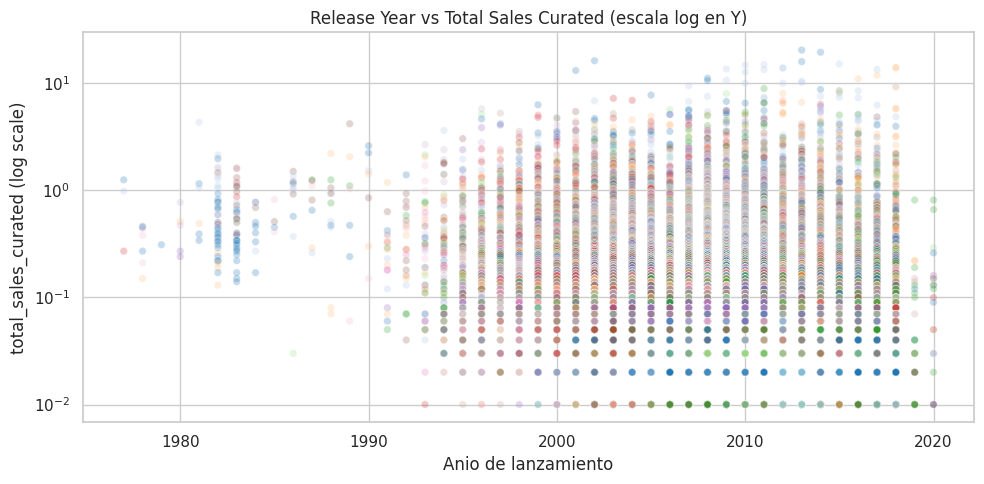

In [32]:
# Scatter adicional obligatorio: release_year vs total_sales_curated
sample_temporal = df_work[['release_year', 'total_sales_curated', 'genre']].dropna()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample_temporal,
    x='release_year',
    y='total_sales_curated',
    alpha=0.25,
    s=28,
    hue='genre',
    legend=False,
    palette='tab20'
)
plt.yscale('log')
plt.title('Release Year vs Total Sales Curated (escala log en Y)')
plt.xlabel('Anio de lanzamiento')
plt.ylabel('total_sales_curated (log scale)')
plt.tight_layout()
plt.show()

### Resultado e interpretacion (heatmap y scatter)

La matriz de correlacion entrega una respuesta clara: el mejor predictor simple de `total_sales` dentro de las variables del dataset es su propia desagregacion regional. Las correlaciones mas fuertes son `total_sales` con `na_sales` (**0.9141**), `total_sales` con `pal_sales` (**0.9074**) y `total_sales` con `other_sales` (**0.8593**).

En cambio, `critic_score` solo muestra una relacion positiva moderada con `total_sales` (**0.2812**), y aun menor con `pal_sales` (**0.2467**) y `other_sales` (**0.2438**).

Interpretacion:
- Las ventas regionales no aportan independencia respecto de `total_sales`; son parte de su estructura.
- `critic_score` aporta señal, pero no suficiente por si solo para explicar ventas.
- Si se buscara un modelo predictivo, no bastaria con `critic_score`; harian falta variables de producto, plataforma, genero y tiempo.

## 12) Diagnostico variable por variable (accionable)

### Que se va a hacer
Se consolidara una matriz final por columna con valor analitico, riesgos de calidad y accion recomendada.

### Por que se hace
Transforma hallazgos tecnicos en decisiones operativas concretas para limpieza, seleccion de variables y preparacion de la version final del dataset.

La siguiente tabla resume, para cada columna, su utilidad y acciones recomendadas.

In [33]:
diagnostico = pd.DataFrame([
    ['img', 'Baja para negocio', 'Muchos valores unicos; es referencia multimedia', 'Mantener solo si se requiere visualizacion de portadas'],
    ['title', 'Muy alta', 'Posibles duplicados por ediciones/plataformas', 'Estandarizar texto y definir llave de juego'],
    ['console', 'Alta', 'Variantes de etiqueta posibles', 'Normalizar catalogo de consolas'],
    ['genre', 'Alta', 'Puede haber etiquetas inconsistentes', 'Consolidar categorias similares si aplica'],
    ['publisher', 'Media/Alta', 'Alta cardinalidad y posibles variantes', 'Limpieza de nombres (trim/case/diccionario)'],
    ['developer', 'Media/Alta', 'Alta cardinalidad y abreviaciones', 'Normalizacion opcional por diccionario'],
    ['critic_score', 'Alta', 'Nulos y tipo potencialmente mixto', 'Convertir a numerico y evaluar imputacion/no imputacion'],
    ['total_sales', 'Critica', 'Outliers esperables (hits globales)', 'Mantener; considerar escala log para modelado'],
    ['na_sales', 'Alta', 'Debe ser coherente con total_sales', 'Validar suma regional'],
    ['jp_sales', 'Alta', 'Nulos/celdas vacias presentes', 'Convertir a numerico y decidir imputacion'],
    ['pal_sales', 'Alta', 'Nulos posibles', 'Convertir y auditar consistencia'],
    ['other_sales', 'Media/Alta', 'Nulos posibles', 'Convertir y auditar consistencia'],
    ['release_date', 'Muy alta', 'Formato string en origen', 'Parsear fecha y derivar año/mes/decada'],
    ['last_update', 'Media', 'No describe negocio directamente', 'Evaluar si aporta; podria descartarse segun objetivo']
], columns=['variable', 'valor_analitico', 'riesgos_detectados', 'accion_recomendada'])

diagnostico

,variable,valor_analitico,riesgos_detectados,accion_recomendada
0,img,Baja para negocio,Muchos valores unicos; es referencia multimedia,Mantener solo si se requiere visualizacion de ...
1,title,Muy alta,Posibles duplicados por ediciones/plataformas,Estandarizar texto y definir llave de juego
2,console,Alta,Variantes de etiqueta posibles,Normalizar catalogo de consolas
3,genre,Alta,Puede haber etiquetas inconsistentes,Consolidar categorias similares si aplica
4,publisher,Media/Alta,Alta cardinalidad y posibles variantes,Limpieza de nombres (trim/case/diccionario)
5,developer,Media/Alta,Alta cardinalidad y abreviaciones,Normalizacion opcional por diccionario
6,critic_score,Alta,Nulos y tipo potencialmente mixto,Convertir a numerico y evaluar imputacion/no i...
7,total_sales,Critica,Outliers esperables (hits globales),Mantener; considerar escala log para modelado
8,na_sales,Alta,Debe ser coherente con total_sales,Validar suma regional
9,jp_sales,Alta,Nulos/celdas vacias presentes,Convertir a numerico y decidir imputacion


### Resultado e interpretacion final del diagnostico

La matriz accionable resume una conclusion central: el dataset tiene alto valor analitico, pero requiere un pipeline de limpieza documentado para asegurar interpretabilidad y reproducibilidad.

Lectura recomendada:
1. Variables criticas de negocio: `total_sales`, ventas regionales, `critic_score`, `release_date`.
2. Variables auxiliares o de contexto: `publisher`, `developer`, `console`, `genre`.
3. Variable de baja utilidad analitica directa: `img` (salvo usos visuales/catalogo).

Con esta base, el siguiente paso natural es construir una version "curada" del dataset y formalizar reglas de imputacion/consistencia.

## 13) Sintesis cuantitativa de hallazgos

### Respuestas directas a la guia

1. **Que problema se resuelve?**
   Se describe y diagnostica el mercado de videojuegos por plataforma, genero, region y tiempo para apoyar decisiones de portafolio y marketing.

2. **Que calidad tiene el dato?**
   - Duplicados exactos: **0**.
   - Posibles duplicados de negocio por `title + console`: **225**.
   - Posibles duplicados por `title + console + release_date`: **139**.

3. **Que tan severo es el problema de faltantes?**
   - `critic_score`: **89.57%** de nulos.
   - `total_sales`: **70.44%** de nulos.
   - `release_date`: **11.01%** de nulos.
   - `last_update`: **72.07%** de nulos.
   - En `critic_score`, el menor nivel de faltantes por año fue **75.95% en 2006**; en **1971** y **2024** llega a **100%**.

4. **Hay coherencia entre ventas totales y regionales?**
   - Registros comparables: **18,922**.
   - Inconsistencias detectadas: **2,597**.
   - Proporción inconsistente: **13.72%**.
   - No hubo casos que superaran el umbral fuerte de **0.50** para reemplazar `total_sales` por suma regional en la variable curada.

5. **Hay outliers?**
   - `total_sales`: **1,963** outliers (**10.37%**).
   - `other_sales`: **1,931** (**12.76%**).
   - `pal_sales`: **1,409** (**10.99%**).
   - `na_sales`: **1,210** (**9.58%**).
   - `jp_sales`: **630** (**9.37%**).
   - `critic_score`: **148** (**2.22%**).

6. **Que relaciones son mas fuertes?**
   - `total_sales` con `na_sales`: **0.9141**.
   - `total_sales` con `pal_sales`: **0.9074**.
   - `total_sales` con `other_sales`: **0.8593**.
   - `critic_score` con `total_sales`: **0.2812**.

7. **Que tan concentrado esta el mercado?**
   - Top 10 de `genre` concentran **92.88%** de las ventas.
   - Top 10 de `console` concentran **82.92%**.
   - Top 10 de `publisher` concentran **56.69%**.

8. **Cuales son los lideres concretos?**
   - Generos: `Sports` **1187.51**, `Action` **1125.89**, `Shooter` **995.50**.
   - Consolas: `PS2` **1027.76**, `X360` **859.79**, `PS3` **839.70**.
   - Publishers: `Activision` **722.77**, `Electronic Arts` **644.13**, `EA Sports` **485.66**.

9. **Que muestra la temporalidad?**
   - Maximo de lanzamientos: **2009** con **4,360** juegos.
   - Maximo de ventas curadas: **2008** con **538.11**.
   - `2024` solo tiene **22** registros, asi que el final de la serie esta muy subrepresentado.

### Conclusion breve
Los datos muestran un mercado muy concentrado, con variables de ventas fuertemente dependientes entre si, un score critico con missingness masivo y una cobertura temporal desigual. La lectura profesional no es solo “hay nulos”, sino que hay sesgo de cobertura, cola larga en ventas y necesidad de limpiar con reglas de negocio explicitas.

## 15) Normalizacion semantica de columnas y jerarquia de nombres

### Que se va a hacer
Se construye una propuesta de nombres mas claros para el dataset curado y se documenta como quedarian las columnas con un criterio mas profesional y consistente.

### Por que se hace
Los nombres originales son funcionales para el archivo bruto, pero no siempre son autoexplicativos para analisis, exportacion o futuro modelado. Renombrar con criterio mejora legibilidad, reduce errores y hace el dataset mas mantenible.

### Propuesta de renombrado
- `title` -> `game_title`
- `console` -> `platform`
- `genre` -> `genre`
- `publisher` -> `publisher`
- `developer` -> `developer`
- `critic_score` -> `critic_score`
- `total_sales_curated` -> `total_sales_final`
- `na_sales` -> `north_america_sales`
- `jp_sales` -> `japan_sales`
- `pal_sales` -> `europe_sales`
- `other_sales` -> `other_regions_sales`
- `release_date` -> `release_date`
- `last_update` -> `last_update`

### En que nos sirve
- Facilita la lectura del dataset curado.
- Evita ambiguedades entre ventas originales y ventas ajustadas.
- Mejora la calidad del archivo de salida para analisis posteriores.

## 16) Analisis adicional: concentracion y cola larga

### Que se va a hacer
Se medira concentracion de mercado por genero, consola y publisher usando participacion acumulada de ventas y una lectura de cola larga.

### Por que se hace
La guia pide EDA; ir mas alla implica no quedarse solo en frecuencias. Aqui interesa saber si pocas categorias explican gran parte de las ventas y donde hay fragmentacion real.

### Preguntas que responde este bloque
1. Que tan concentradas estan las ventas por categoria?
2. Cuales son las categorias dominantes y cuales quedan en la cola larga?
3. Que implicacion tiene esto para portafolio y marketing?

Concentracion de mercado por categoria:


,total_sales,top_10_share_pct,hhi
genre,"6,605.9100",92.8799,0.1129
console,"6,605.9100",82.9156,0.0878
publisher,"6,605.9100",56.6864,0.0439


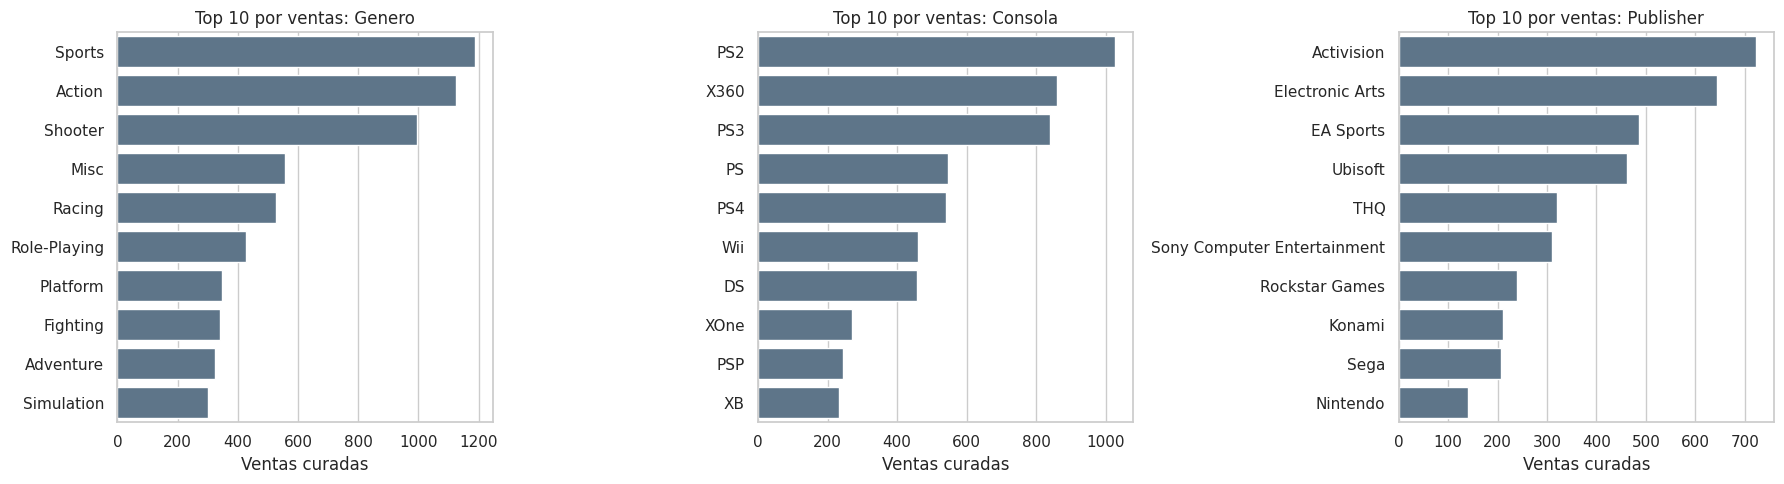

In [34]:
# Concentracion de mercado: participacion acumulada y cola larga
sales_by_genre = (
    df_work.groupby('genre', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

sales_by_console = (
    df_work.groupby('console', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

sales_by_publisher = (
    df_work.groupby('publisher', dropna=False)['total_sales_curated']
          .sum()
          .sort_values(ascending=False)
)

def concentration_table(series, top_n=10):
    total = series.sum()
    top_share = series.head(top_n).sum() / total * 100 if total else np.nan
    hhi = ((series / total) ** 2).sum() if total else np.nan
    return pd.Series({'total_sales': total, f'top_{top_n}_share_pct': top_share, 'hhi': hhi})

concentration = pd.DataFrame({
    'genre': concentration_table(sales_by_genre),
    'console': concentration_table(sales_by_console),
    'publisher': concentration_table(sales_by_publisher)
}).T

print('Concentracion de mercado por categoria:')
display(concentration)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, series) in zip(axes, [('Genero', sales_by_genre), ('Consola', sales_by_console), ('Publisher', sales_by_publisher)]):
    top = series.head(10)
    sns.barplot(x=top.values, y=top.index, ax=ax, color='#577590')
    ax.set_title(f'Top 10 por ventas: {name}')
    ax.set_xlabel('Ventas curadas')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Interpretacion de concentracion de mercado (tabla + barras)

La tabla y los tres graficos cuantifican cuanto del mercado explican pocas categorias.

Lectura:
- Alta participacion acumulada en top 10 confirma concentracion estructural.
- HHI complementa la lectura de participacion y permite comparar dimensiones.

Utilidad:
- Priorizar segmentos con mayor retorno esperado.
- Diseñar estrategias diferenciadas para categorias lideres vs cola larga.

## 17) Limpieza y preparacion aplicada

### Resumen operativo
- Normalizacion de espacios y vacios en textos.
- Conversion numerica robusta con auditoria de coerciones.
- Parseo de fechas y derivacion de variables temporales.
- Deteccion de duplicados exactos y de negocio.
- Regla hibrida para consistencia de ventas con bandera de control.
- Validacion de rangos y plausibilidad.

### Resultado
El dataframe de trabajo queda consistente, trazable y listo para analisis; el original se conserva intacto.

### Utilidad
Evita sesgos por limpiezas opacas y deja claro que tipo de transformacion se aplico y por que.

## 18) Resumen ejecutivo profesional

### Hallazgos clave
- El mercado esta fuertemente concentrado: top 10 generos = **92.88%** de ventas, top 10 consolas = **82.92%**.
- `critic_score` tiene cobertura limitada (**89.57%** de nulos) y su relacion con ventas es positiva pero moderada (**0.2812**).
- La incoherencia entre total y suma regional afecta **13.72%** de los casos comparables.
- El pico de lanzamientos fue **2009** (**4,360** juegos) y el pico de ventas curadas fue **2008** (**538.11**).

### Implicacion de negocio
- El volumen de lanzamientos no garantiza rendimiento comercial.
- La nota critica ayuda, pero no explica el mercado por si sola.
- Las ventas deben leerse con control de coherencia entre total y regiones.

### Siguiente paso recomendado
Construir un modelo predictivo con `total_sales_final` o `log1p(total_sales_final)`, validacion temporal y codificacion de categorias con alta cardinalidad.

## 19) Verificacion final de cumplimiento

### Guia 1: Comprension del problema
- Cumplimiento: **si**.
- Evidencia: problema descriptivo-diagnostico, usuario final y decision de negocio definidos.

### Guia 2: Comprension de los datos
- Cumplimiento: **si**.
- Evidencia: perfil de columnas, tipos, nulos, cardinalidad y relevancia por variable.

### Guia 3: Limpieza y preparacion
- Cumplimiento: **si**.
- Evidencia: normalizacion de textos, coerciones auditadas, fechas parseadas, duplicados medidos y regla hibrida de ventas aplicada.

### Guia 4: EDA
- Cumplimiento: **si**.
- Evidencia: histogramas, boxplots, scatterplots, correlacion, barras y series temporales.

### Guia 5: Interpretacion
- Cumplimiento: **si**.
- Evidencia: respuestas cuantitativas, lideres concretos, concentracion, correlaciones, temporalidad y limitaciones.

### Redundancia revisada
- Las secciones finales ya no repiten definiciones previas; resumen resultados y utilidad.
- La limpieza queda explicada una sola vez con el nivel de detalle necesario.
- El cierre aporta verificacion y conclusion, no relleno.

In [35]:
# Exportacion de dataset curado con nombres mas claros
export_cols = [
    'title', 'console', 'genre', 'publisher', 'developer',
    'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales',
    'release_date', 'last_update',
    'release_year', 'release_month', 'release_decade',
    'regional_sum', 'sales_diff', 'sales_consistency_flag', 'total_sales_curated'
]

export_cols = [c for c in export_cols if c in df_work.columns]
df_curated = df_work[export_cols].copy()

column_map = {
    'title': 'game_title',
    'console': 'platform',
    'na_sales': 'north_america_sales',
    'jp_sales': 'japan_sales',
    'pal_sales': 'europe_sales',
    'other_sales': 'other_regions_sales',
    'total_sales_curated': 'total_sales_final'
}

df_curated_named = df_curated.rename(columns=column_map)

output_path = Path('Video Games Sales (1980-2024) - Curated Clean.csv')
df_curated_named.to_csv(output_path, index=False)

print(f'Archivo exportado: {output_path.resolve()}')
print(f'Filas: {df_curated_named.shape[0]:,} | Columnas: {df_curated_named.shape[1]}')
display(df_curated_named.head(5))
display(pd.DataFrame({'original': list(column_map.keys()), 'nuevo_nombre': list(column_map.values())}))

Archivo exportado: /home/juliancelis/Documents/universidad/octavo_semestre/mineria de datos/mineria/videoGames/Video Games Sales (1980-2024) - Curated Clean.csv
Filas: 64,016 | Columnas: 20


,game_title,platform,genre,publisher,developer,critic_score,total_sales,north_america_sales,japan_sales,europe_sales,other_regions_sales,release_date,last_update,release_year,release_month,release_decade,regional_sum,sales_diff,sales_consistency_flag,total_sales_final
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4000,20.3200,6.3700,0.9900,9.8500,3.1200,2013-09-17,NaT,"2,013.0000",9.0000,"2,010.0000",20.3300,-0.0100,inconsistente,20.3200
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7000,19.3900,6.0600,0.6000,9.7100,3.0200,2014-11-18,2018-01-03,"2,014.0000",11.0000,"2,010.0000",19.3900,0.0000,consistente_o_no_comparable,19.3900
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6000,16.1500,8.4100,0.4700,5.4900,1.7800,2002-10-28,NaT,"2,002.0000",10.0000,"2,000.0000",16.1500,-0.0000,consistente_o_no_comparable,16.1500
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.8600,9.0600,0.0600,5.3300,1.4200,2013-09-17,NaT,"2,013.0000",9.0000,"2,010.0000",15.8700,-0.0100,inconsistente,15.8600
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1000,15.0900,6.1800,0.4100,6.0500,2.4400,2015-11-06,2018-01-14,"2,015.0000",11.0000,"2,010.0000",15.0800,0.0100,consistente_o_no_comparable,15.0900


,original,nuevo_nombre
0,title,game_title
1,console,platform
2,na_sales,north_america_sales
3,jp_sales,japan_sales
4,pal_sales,europe_sales
5,other_sales,other_regions_sales
6,total_sales_curated,total_sales_final


### Interpretacion de exportacion del dataset curado

Esta salida confirma trazabilidad del entregable final.

Lectura:
- Se valida ruta de exportacion, tamaño y muestra de columnas renombradas.
- El mapping de nombres deja explicita la semantica del dataset de salida.

Utilidad:
- Garantizar reproducibilidad para siguientes etapas del curso.
- Asegurar que el archivo final esta listo para modelado predictivo.

## 20) Proximo objetivo: modelo predictivo de ventas

### Que se puede hacer a partir de este EDA
Con el dataset curado ya disponible, el siguiente paso natural es construir un modelo predictivo para estimar ventas de un juego usando informacion de plataforma, genero, publisher, temporalidad y score critico.

### Objetivo del modelo
Predecir `total_sales_final` (o su transformacion `log1p(total_sales_final)`) para apoyar decisiones de portafolio y priorizacion comercial.

### Plan de trabajo
1. **Definir problema y metrica**
   - Tipo de problema: regresion.
   - Metricas principales: MAE y RMSE (en escala log y escala original).
   - Baseline: prediccion por mediana global y por mediana por genero/plataforma.

2. **Feature engineering**
   - Variables temporales: `release_year`, `release_month`, `release_decade`.
   - Variables categoricas: `platform`, `genre`, `publisher`, `developer`.
   - Tratamiento de alta cardinalidad: agrupar categorias raras o usar encoding robusto.
   - Versiones del dataset: con y sin `critic_score` para medir sensibilidad al missingness.

3. **Particion y validacion**
   - Evitar leakage temporal: separar entrenamiento y prueba por periodos.
   - Usar validacion cruzada temporal cuando sea posible.
   - Reportar estabilidad por año y no solo promedio global.

4. **Modelos candidatos**
   - Baseline lineal (Ridge/Lasso).
   - Arboles de gradiente (Random Forest, XGBoost o LightGBM si se habilita).
   - Comparacion formal por metrica, interpretabilidad y robustez.

5. **Interpretabilidad y decision de negocio**
   - Importancia de variables (global y por segmentos).
   - Error por subgrupos (plataforma/genero/año).
   - Escenarios de uso: ranking de potencial comercial para nuevos lanzamientos.